# IND320 Compulsory Assignment 1

## Project links

- **GitHub repository:** https://github.com/VasiliiAnderson/ind320-project
- **Streamlit app:** https://vasilii-ind320.streamlit.app/

## Task description

#### GitHub and Streamlit.app accounts

- Prepare a GitHub account and create a public repository for your project work. Addresses on streamlit.app must be unique, so include your GitHub username or similar in the repository name. Report the Streamlit address and GitHub repository address in the Jupyter Notebook.
- Log in to [share.streamlit.io](https://share.streamlit.io/) using your GitHub account.
- Create a minimum working example of a Streamlit app, push it to GitHub, and ensure it works at `https://[yourproject].streamlit.app/`

#### Jupyter Notebook

- Read the `reservoirs.csv` file using Pandas (located in `D2Dbook/data`).
- Rename headers to English and understandable.
- Print its contents in a relevant way.
- Plot each column separately.
- Plot all columns together. Consider how to make this natural, given that the scales are different.
- Remember to fill in the log and AI usage mentioned in the General section above.

#### Streamlit app

- Create a Streamlit app including:
  - `requirements.txt` or `uv.lock` for package dependencies.
  - Four pages with dummy headers and test content for now, using separate `.py` files:
    1. The front/home page should have a sidebar menu with navigation options to the other pages.
    2. On the second page:
       - A table showing the imported data.
       - Use the row-wise `LineChartColumn()` to display the first month of the data series.
       - There should be one row in the table for each column of the imported data.
    3. On the third page:
       - A plot of the imported data, including a header, axis titles, and other relevant formatting.
       - A drop-down menu using `st.selectbox` for choosing any single column in the CSV or all columns together.
       - A selection slider using `st.select_slider` to select a subset of the months. The default should be the first month.
  - Data should be read from a local CSV file (`reservoirs.csv`), using caching for app speed.
  - In part 2 of the project, the local CSV file will be removed and MongoDB will be used instead.

#### Screencast

- Create a 5-minute screencast where you briefly showcase the running app and explain what the code does.

## 1. Setup and Imports

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Data Loading

In [24]:
data_path = Path("../data/reservoirs.csv")

df = pd.read_csv(data_path)

df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 4. Data Preparation

In [25]:
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_fill_level",
    "endring_fyllingsgrad": "change_in_fill_level",
}

df = df.rename(columns=column_names)

In [26]:
df["date"] = pd.to_datetime(df["date"])

df["next_publication_date"] = pd.to_datetime(
    df["next_publication_date"],
    errors="coerce"
)

In [27]:
df = (
    df
    .sort_values(["date", "area_number"])
    .reset_index(drop=True)
)

df.head()

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,1-01-01,0.752703,-0.144430
1,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,1-01-01,0.734888,-0.113421
2,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,1-01-01,0.798825,-0.162787
3,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,1-01-01,0.777604,-0.146657
4,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,1-01-01,0.744693,-0.135837


## 5. Data Exploration

In [28]:
display(df.head(10))

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,1-01-01,0.752703,-0.144430
1,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,1-01-01,0.734888,-0.113421
2,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,1-01-01,0.798825,-0.162787
3,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,1-01-01,0.777604,-0.146657
4,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,1-01-01,0.744693,-0.135837
5,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,1-01-01,0.596027,0.006349
6,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,1-01-01,0.661432,-0.094525
7,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,1-01-01,0.801348,-0.242484
8,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,1-01-01,0.614288,0.002160
9,1995-01-15,NO,0,1995,2,0.582372,87.437580,50.921207,1-01-01,0.608274,-0.025902


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[us]
 1   area_type                 14877 non-null  str           
 2   area_number               14877 non-null  int64         
 3   iso_year                  14877 non-null  int64         
 4   iso_week                  14877 non-null  int64         
 5   fill_level                14877 non-null  float64       
 6   capacity_twh              14877 non-null  float64       
 7   stored_energy_twh         14877 non-null  float64       
 8   next_publication_date     14877 non-null  datetime64[us]
 9   previous_week_fill_level  14877 non-null  float64       
 10  change_in_fill_level      14877 non-null  float64       
dtypes: datetime64[us](2), float64(5), int64(3), str(1)
memory usage: 1.3 MB


In [30]:
display(df.describe())

,date,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0484-02-28 12:07:22.105272,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0001-01-01 00:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0001-01-01 00:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0001-01-01 00:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0001-01-01 00:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


In [31]:
df.columns

Index(['date', 'area_type', 'area_number', 'iso_year', 'iso_week',
       'fill_level', 'capacity_twh', 'stored_energy_twh',
       'next_publication_date', 'previous_week_fill_level',
       'change_in_fill_level'],
      dtype='str')

## 6. Individual Plots

The numerical reservoir measurements are plotted separately against time to inspect their development and variation.

### Numerical measurements

The dataset contains observations for several geographical aggregation levels. 
To avoid mixing different areas within the same time series, the plots below 
use the national observations (`area_type = "NO"` and `area_number = 0`). 
Each numerical measurement is plotted separately over time.

In [32]:
df[["area_type", "area_number"]].drop_duplicates().sort_values(
    ["area_type", "area_number"]
)

,area_type,area_number
1,EL,1
3,EL,2
5,EL,3
7,EL,4
8,EL,5
0,NO,0
2,VASS,1
4,VASS,2
6,VASS,3


In [33]:
# Selecting the national time series only
norway_data = (
    df[
        (df["area_type"] == "NO") &
        (df["area_number"] == 0)
    ]
    .sort_values("date")
)

In [34]:
measurement_columns = [
    "fill_level",
    "capacity_twh",
    "stored_energy_twh",
    "previous_week_fill_level",
    "change_in_fill_level",
]

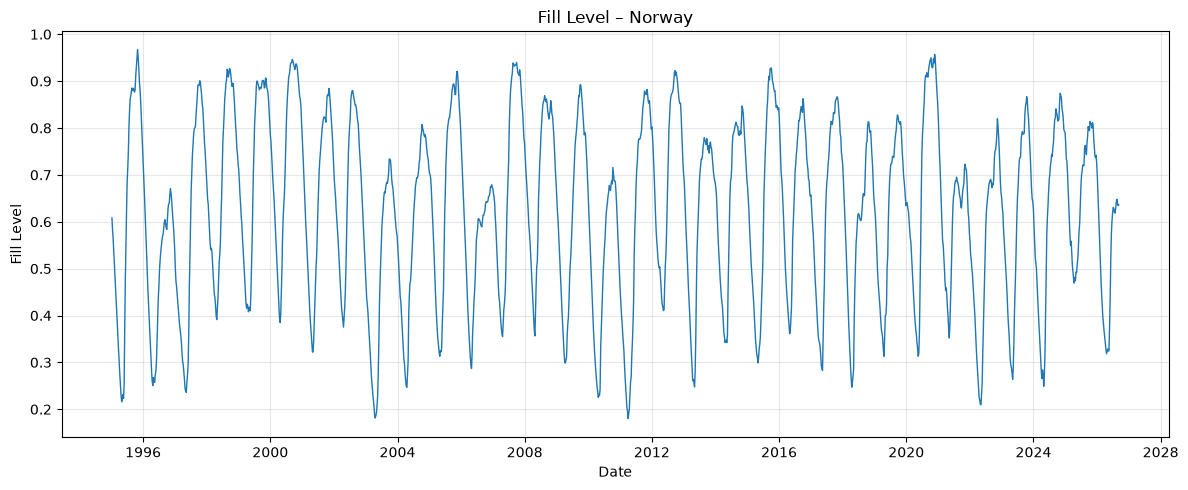

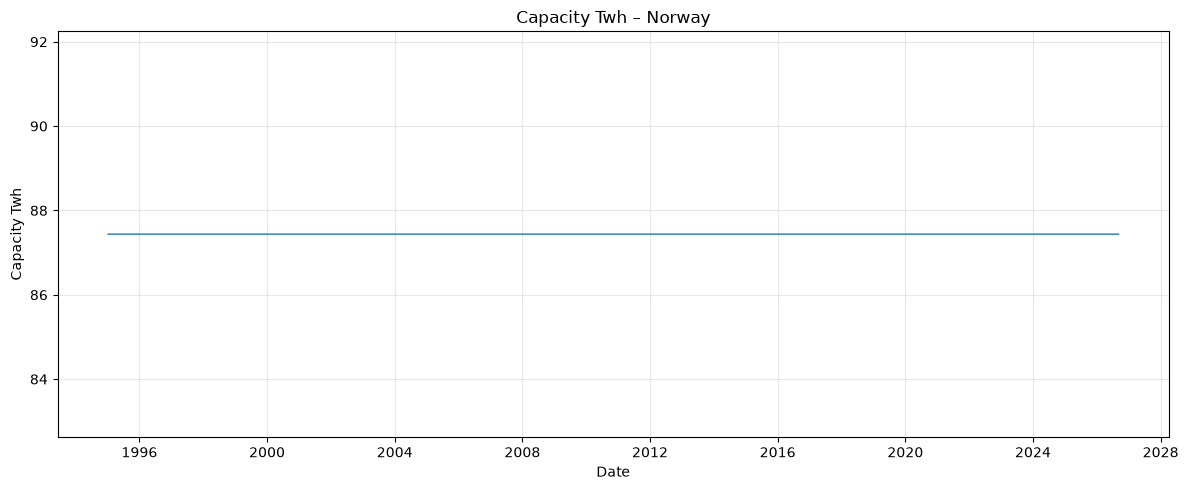

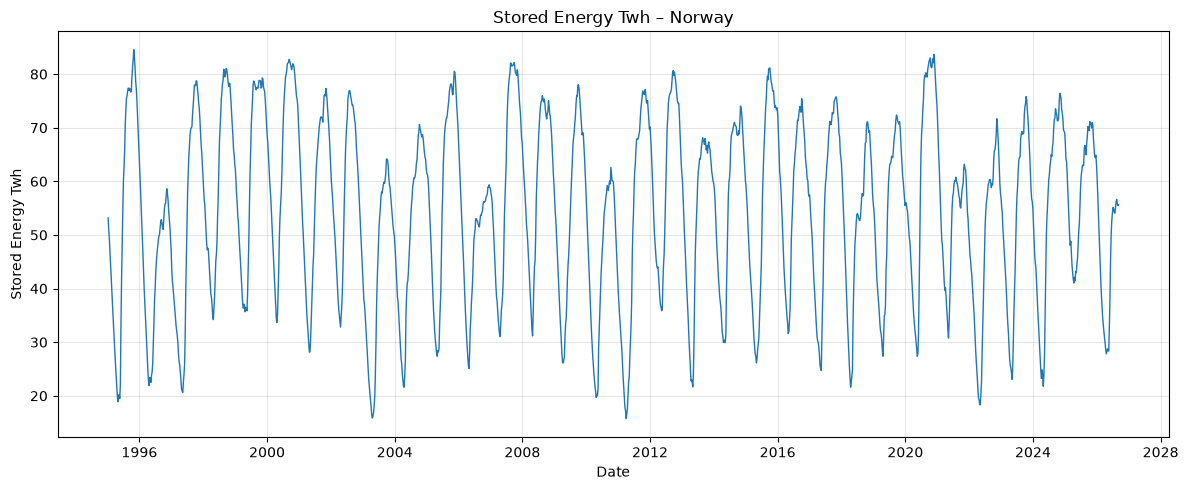

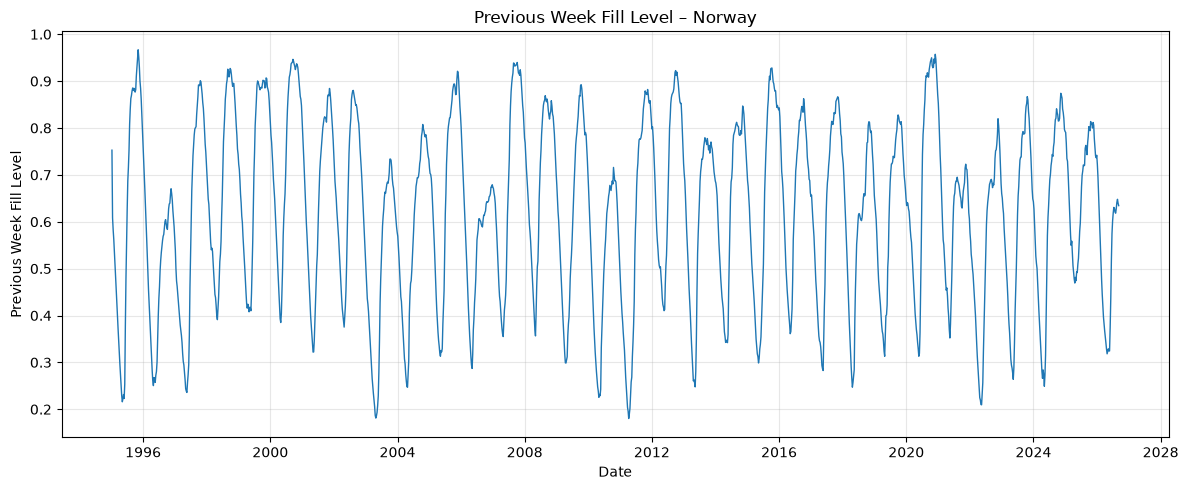

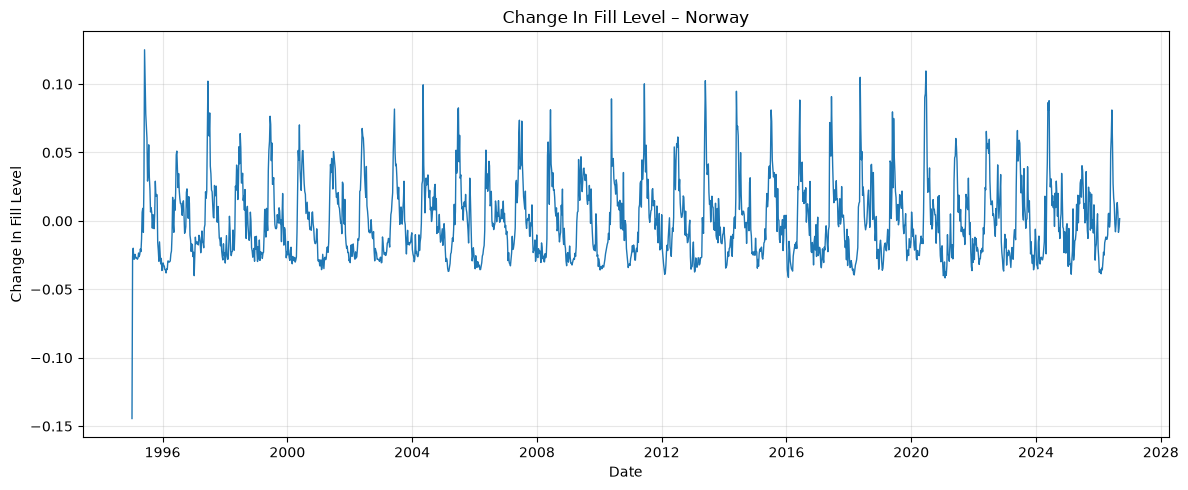

In [36]:
for column in measurement_columns:
    plt.figure(figsize=(12, 5))

    plt.plot(
        norway_data["date"],
        norway_data[column],
        linewidth=1
    )

    plt.title(f"{column.replace('_', ' ').title()} – Norway")
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [37]:
print("Number of unique values:", norway_data["capacity_twh"].nunique())
print("Minimum:", norway_data["capacity_twh"].min())
print("Maximum:", norway_data["capacity_twh"].max())

Number of unique values: 1
Minimum: 87.43758
Maximum: 87.43758


In [38]:
df[["date", "area_number"]].head(20)

,date,area_number
0,1995-01-08,0
1,1995-01-08,1
2,1995-01-08,1
3,1995-01-08,2
4,1995-01-08,2
5,1995-01-08,3
6,1995-01-08,3
7,1995-01-08,4
8,1995-01-08,5
9,1995-01-15,0


In [39]:
df["area_number"].unique()

array([0, 1, 2, 3, 4, 5])

In [40]:
print(df["area_type"].unique())

<ArrowStringArray>
['NO', 'EL', 'VASS']
Length: 3, dtype: str


### Categorical and time-related variables

The remaining columns mainly describe geographical areas and time identifiers rather than continuous measurements. Appropriate frequency plots are therefore used instead of time-series plots.

1. area_type

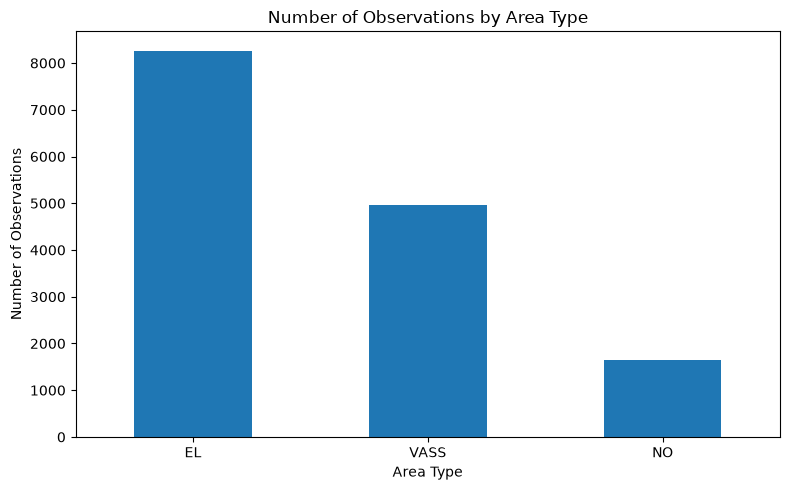

In [41]:
area_type_counts = df["area_type"].value_counts()

plt.figure(figsize=(8, 5))
area_type_counts.plot(kind="bar")

plt.title("Number of Observations by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2. area_number

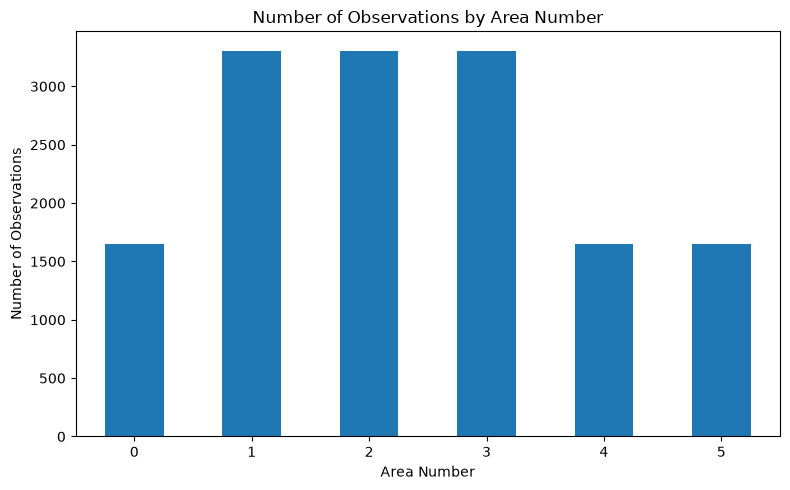

In [42]:
area_number_counts = df["area_number"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
area_number_counts.plot(kind="bar")

plt.title("Number of Observations by Area Number")
plt.xlabel("Area Number")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3. iso_year

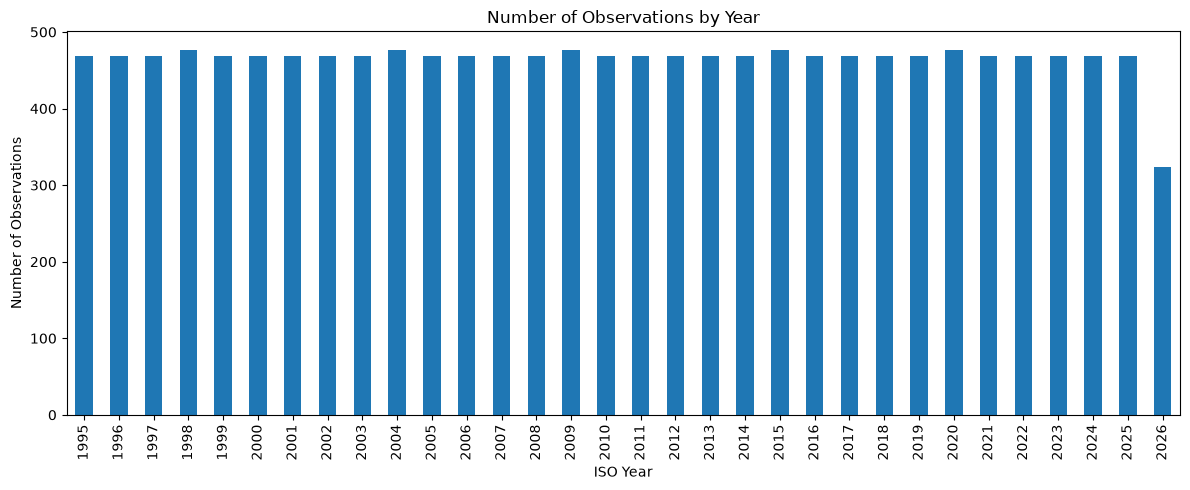

In [43]:
year_counts = df["iso_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
year_counts.plot(kind="bar")

plt.title("Number of Observations by Year")
plt.xlabel("ISO Year")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

4. iso_week

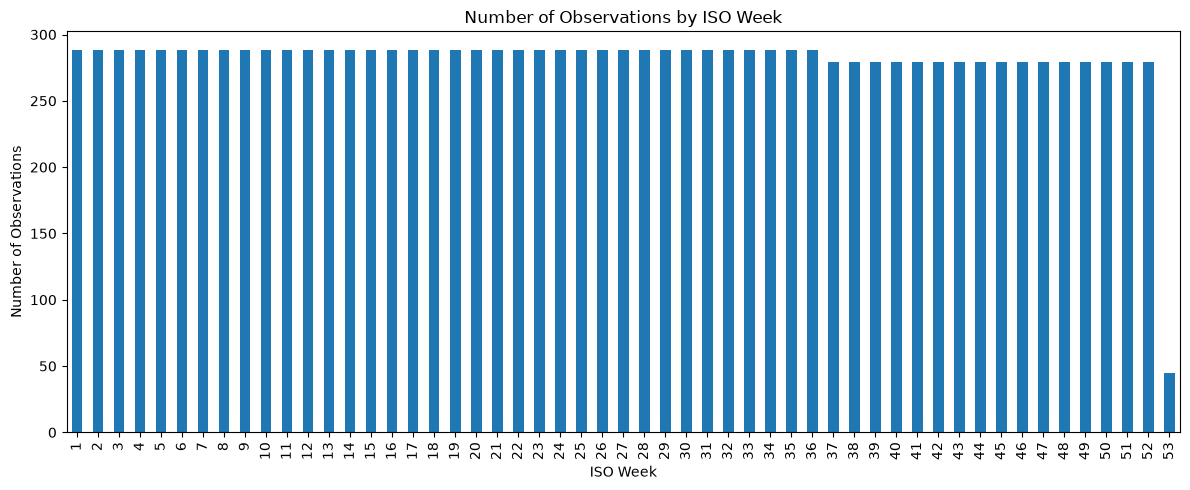

In [44]:
week_counts = df["iso_week"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
week_counts.plot(kind="bar")

plt.title("Number of Observations by ISO Week")
plt.xlabel("ISO Week")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

5. date

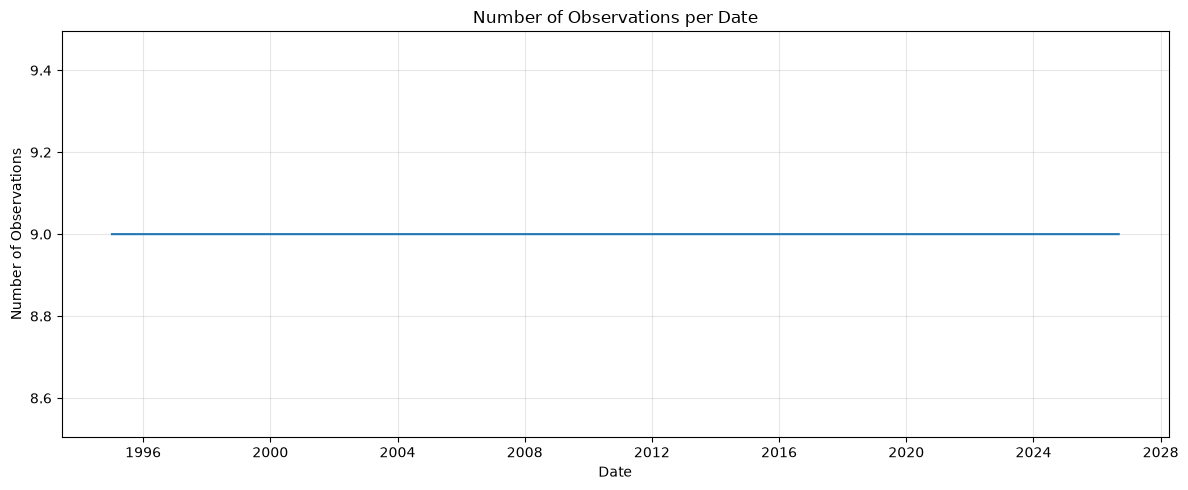

In [45]:
date_counts = df["date"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(date_counts.index, date_counts.values)

plt.title("Number of Observations per Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Combined Plot

The numerical reservoir measurements have different units and scales, which makes a direct comparison difficult. To make the time-series patterns comparable, the variables are normalised to a common scale from 0 to 1.

Only meaningful reservoir measurements are included. Identifier, categorical and administrative variables are excluded from the combined plot.

In [49]:
# Jeg ville utelatt capacity_twh fra dette plottet fordi vi nettopp så at den er konstant for Norge. En konstant variabel tilfører ingen informasjon om utviklingen over tid og kan heller ikke normaliseres på vanlig måte.

combined_columns = [
    "fill_level",
    "stored_energy_twh",
    "previous_week_fill_level",
    "change_in_fill_level",
]

In [50]:
# Create a copy containing only the measurements used in the combined plot
normalized_data = norway_data[combined_columns].copy()

# Min-max normalisation:
# each variable is transformed to values between 0 and 1
for column in combined_columns:
    minimum = normalized_data[column].min()
    maximum = normalized_data[column].max()

    normalized_data[column] = (
        normalized_data[column] - minimum
    ) / (maximum - minimum)

normalized_data.head()

,fill_level,stored_energy_twh,previous_week_fill_level,change_in_fill_level
0,0.544098,0.544098,0.727714,0.000000
9,0.511173,0.511173,0.544109,0.439810
18,0.485800,0.485800,0.511204,0.461793
27,0.450329,0.450329,0.485808,0.432379
36,0.414707,0.414707,0.450310,0.432013


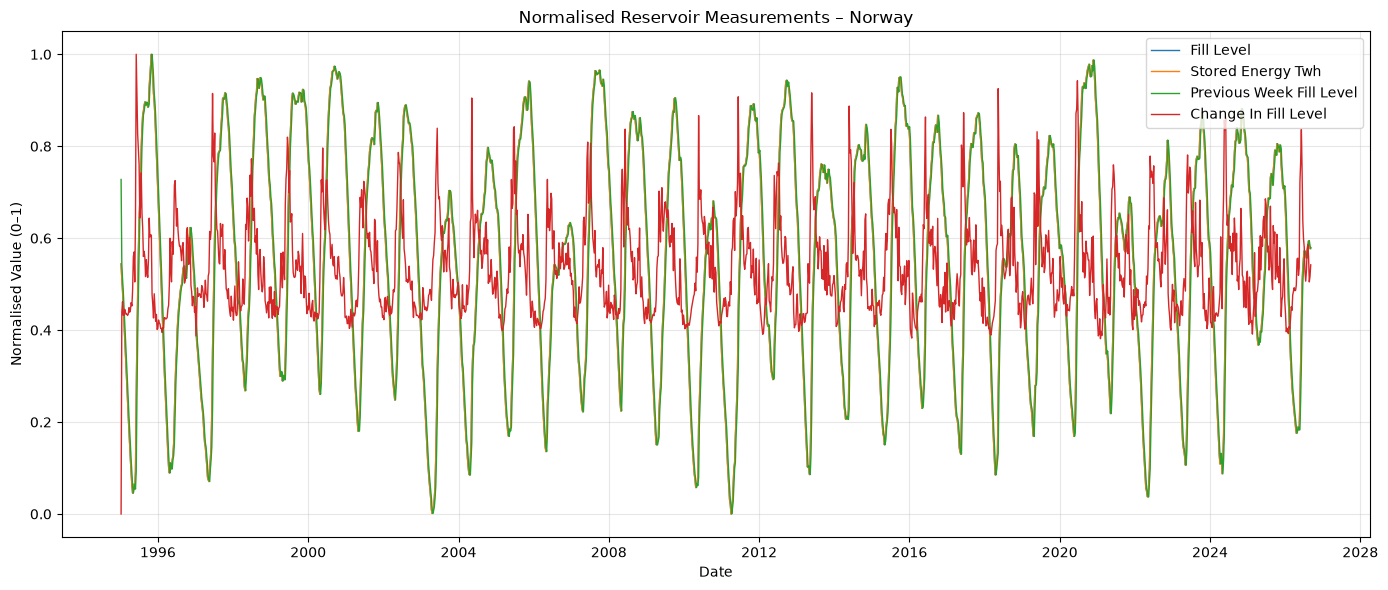

In [51]:
plt.figure(figsize=(14, 6))

for column in combined_columns:
    plt.plot(
        norway_data["date"],
        normalized_data[column],
        label=column.replace("_", " ").title(),
        linewidth=1
    )

plt.title("Normalised Reservoir Measurements – Norway")
plt.xlabel("Date")
plt.ylabel("Normalised Value (0–1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The normalised plot shows that `fill_level`, `stored_energy_twh`, and 
`previous_week_fill_level` follow very similar patterns over time. 
This is expected because stored energy is closely related to reservoir fill level.

The `change_in_fill_level` variable behaves differently, as it represents 
weekly changes rather than the absolute level of the reservoirs.

`capacity_twh` is not included in the combined plot because it is constant 
for the national observations and therefore does not provide a meaningful 
time-series pattern.

## 8. Streamlit Application

## 9. AI Usage

## 10. Work Log